# Figure S14B-F. Reference-based activity filters

In [1]:
### load packages
import math
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [ ]:
### Create samplesheet for liang enriched paired samples
# liang_enriched_samples.tsv identified by finding samples with a viromeQC score >= 50
# downloaded from here: https://pmc.ncbi.nlm.nih.gov/articles/instance/10925137/bin/media-3.xlsx
# liang_sample_file.tsv is the file downloaded from SRA

liang_enriched_samples = set(
    pl.read_csv('liang_enriched_samples.tsv', separator='\t')
        .with_columns([
            pl.col('sample_id').str.replace(r'^D', '')
        ])
        ['sample_id']
)

liang_enriched_paired_samples = set(
    pl.read_csv('liang_sample_file.tsv', separator='\t', ignore_errors=True)
        .with_columns([
            pl.col('Sample_id').cast(pl.String)
        ])
        .filter(
            (pl.col('Sample_id').is_in(liang_enriched_samples)) &
            (pl.col('Note').str.contains('infant stool')) &
            (~pl.col('Note').str.starts_with('RNA '))
        )
        .group_by('Sample_id')
        .len()
        .filter(pl.col('len') == 2)
        ['Sample_id']
)

(
    pl.read_csv('liang_sample_file.tsv', separator='\t', ignore_errors=True)
        .with_columns([
            pl.col('Sample_id').cast(pl.String)
        ])
        .filter(
            (pl.col('Sample_id').is_in(liang_enriched_paired_samples)) &
            (~pl.col('Note').str.starts_with('RNA ')) &
            (pl.col('Library_type').is_in(['Virome sequencing', 'Total microbial shotgun  sequencing']))
        )
        .with_columns([
            pl.when(pl.col('Library_type') == 'Virome sequencing').then(pl.lit('enriched')).otherwise(pl.lit('unenriched')).alias('sample_type')
        ])
        .with_columns([
            ('liang_' + pl.col('Sample_id') + '_' + pl.col('sample_type')).alias('sample'),
            pl.col('Bioproject_accession').alias('bioproject'),
            ('liang_' + pl.col('Sample_id')).alias('group'),
            pl.col('Biosample_accession').alias('biosample'),
            pl.col('Accession').alias('acc'),
            pl.lit(None).alias('fastq_1'),
            pl.lit(None).alias('fastq_2')
        ])
        [['sample', 'bioproject', 'group', 'biosample', 'acc', 'fastq_1', 'fastq_2']]
        .write_csv('liang_enriched_paired_samplesheet.csv', separator=',')
)

In [ ]:
%%bash
### run through UHVDB/toolkit
mkdir -p activity_profiling/liang_enriched_results
cd activity_profiling/liang_enriched_results

nextflow run /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit \
    -profile uw_hyak \
    -w /gscratch/scrubbed/carsonjm/2026.03.26-liang_enriched_results/work \
    --input /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/activity_profiling/liang_enriched_paired_samplesheet.csv \
    --db_dir /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases \
    --checkv_db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/checkv_db/checkv_db_2026-03-26-2 \
    --output_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/activity_profiling/liang_enriched_results \
    --uhvdb_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2 \
    --hyak_partition="stf" \
    --hyak_queue="ckpt" \
    --new_release_id="2026-04-03" \
    --run_reference_analyze=true \
    --bacterial_sylph_db=/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/virome_profiling/gtdb-r226-c1000-dbv1.syldb \
    --run_assembly_analyze=true

In [3]:
%%bash
### Count number of species reps
zgrep -c "^>" /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_reps.fna.gz

199442


In [2]:
### load coverm results to identify viruses detected in bulk and enriched
df_lst = []

for file in glob.glob('activity_profiling/liang_enriched_results/2026-04-03_outputs/referenceanalyze/coverm/*/*.coverm.tsv.gz'):
    sample_id = file.split('/')[-1].split('.')[0]
    group = sample_id.rsplit('_', 1)[0]
    df = (
        pl.read_csv(file, separator='\t', new_columns=['contig_id', 'trimmed_mean', 'mean', 'variance', 'covered_bases', 'length'])
            .with_columns([
                pl.lit(sample_id).alias('sample_id'),
                pl.lit(group).alias('group')
            ])
            .with_columns([
                (pl.col('covered_bases')/pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
    )
    df_lst.append(df)

coverm_df = pl.concat(df_lst)

In [3]:
# map from original id to species
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep', 'cluster_id']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .filter((pl.col('new_id') == pl.col('genomovar_rep')))
        .unique('genomovar_rep')
)

In [4]:
### load UHVDB species rep info
uhvdb_info = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_info.tsv.gz', separator='\t')
    .filter(pl.col('uhvdb_id') == pl.col('votu_rep'))
    .unique(pl.col('uhvdb_id'))
)

lifestyle_df = (
    pl.read_csv('../figure_3/uhvdb_v4_lifestyle.tsv', separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .with_columns([
            pl.when(
                (pl.col('topology') == 'Provirus') |
                (pl.col('provirus') == 'Yes') |
                (pl.col('temperate') > 0.5) |
                (pl.col('phrog_integrases') > 0) |
                (pl.col('phrog_integration_excision') > 0)
            )
            .then(pl.lit('hc_temperate'))
            .when(
                (pl.col('topology') == 'Provirus') |
                (pl.col('provirus') == 'Yes') |
                (pl.col('temperate') > 0.5) |
                (pl.col('phrog_integrases') > 0) |
                (pl.col('phrog_integration_excision') > 0)
                | (pl.col('empathi_integration') > 0)
            )
            .then(pl.lit('lc_temperate'))
            .otherwise(pl.lit('virulent'))
            .alias('lifestyle'),
            (
                (pl.col('topology') == 'Provirus').fill_null(False).cast(pl.UInt8) +
                (pl.col('provirus') == 'Yes').fill_null(False).cast(pl.UInt8) +
                (pl.col('temperate') > 0.5).fill_null(False).cast(pl.UInt8) +
                (pl.col('phrog_integrases') > 0).fill_null(False).cast(pl.UInt8) +
                (pl.col('phrog_integration_excision') > 0).fill_null(False).cast(pl.UInt8) +
                (pl.col('empathi_integration') > 0).fill_null(False).cast(pl.UInt8)
            ).alias('temperate_signal_count')
        ])
        .group_by('votu_rep')
        .agg([
            # identify most prevalent lifestyle
            pl.col('lifestyle').value_counts(sort=True).first().struct.field('lifestyle').alias('lifestyle'),
            # identify counts of most prev lifestyle
            pl.col('lifestyle').value_counts(sort=True).first().struct.field('count').alias('lifestyle_count'),
            # identify total counts of all lifestyles
            pl.len().alias('total_count'),
            pl.col('temperate_signal_count').median().alias('temperate_signal_count'),
            pl.col('virulent').median().alias('bacphlip_virulent_score')
        ])
        .with_columns([
            (pl.col('lifestyle_count')/pl.col('total_count')).alias('lifestyle_proportion')
        ])
)

In [5]:
taxonomy_df = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_ictv_taxonomy.tsv.gz', separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .sort('normscore', descending=True)
        .unique('uhvdb_id', maintain_order=True)
        .group_by('votu_rep')
        .agg([
            # identify most prevalent lifestyle
            pl.col('Family').value_counts(sort=True).first().struct.field('Family').alias('Family'),
            # identify counts of most prev lifestyle
            pl.col('Family').value_counts(sort=True).first().struct.field('count').alias('family_count'),
            # identify most prevalent lifestyle
            pl.col('Class').value_counts(sort=True).first().struct.field('Class').alias('Class'),
            # identify counts of most prev lifestyle
            pl.col('Class').value_counts(sort=True).first().struct.field('count').alias('class_count'),
            # identify total counts of all lifestyles
            pl.len().alias('total_count'),
            pl.col('normscore').median()
        ])
        .with_columns([
            (pl.col('family_count')/pl.col('total_count')).alias('family_proportion'),
            (pl.col('class_count')/pl.col('total_count')).alias('class_proportion')
        ])
)

phist_df = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_phisthost.tsv.gz', separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .group_by(['votu_rep', 'rank'])
        .agg([
            # identify most prevalent lifestyle
            pl.col('consensus_taxonomy').value_counts(sort=True).first().struct.field('consensus_taxonomy').alias('consensus_taxonomy'),
            # identify counts of most prev lifestyle
            pl.col('consensus_taxonomy').value_counts(sort=True).first().struct.field('count').alias('phist_host_count'),
            # identify total counts of all lifestyles
            pl.len().alias('total_phist_count')
        ])
        .with_columns([
            (pl.col('phist_host_count')/pl.col('total_phist_count')).alias('phist_agreement')
        ])
)

crispr_df = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_crisprhost.tsv.gz', separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .group_by(['votu_rep', 'rank'])
        .agg([
            # identify most prevalent lifestyle
            pl.col('top_taxonomy').value_counts(sort=True).first().struct.field('top_taxonomy').alias('top_taxonomy'),
            # identify counts of most prev lifestyle
            pl.col('top_taxonomy').value_counts(sort=True).first().struct.field('count').alias('crispr_count'),
            # identify total counts of all lifestyles
            pl.len().alias('total_crispr_count'),
            pl.col('total_connections').median().alias('connection_count')
        ])
        .with_columns([
            (pl.col('crispr_count')/pl.col('total_crispr_count')).alias('crispr_proportion')
        ])
)

In [6]:
crispr_df_flat = (
    crispr_df
    .group_by('votu_rep')
        .agg([
            pl.col('top_taxonomy').filter(pl.col('rank') == 'species').first().alias('crispr_species'),
            pl.col('crispr_count').filter(pl.col('rank') == 'species').first().alias('crispr_species_count'),
            pl.col('total_crispr_count').filter(pl.col('rank') == 'species').first().alias('crispr_species_total'),
            pl.col('crispr_proportion').filter(pl.col('rank') == 'species').first().alias('crispr_species_proportion'),
            pl.col('connection_count').filter(pl.col('rank') == 'species').first().alias('crispr_species_connection_count'),

            pl.col('top_taxonomy').filter(pl.col('rank') == 'genus').first().alias('crispr_genus'),
            pl.col('crispr_count').filter(pl.col('rank') == 'genus').first().alias('crispr_genus_count'),
            pl.col('total_crispr_count').filter(pl.col('rank') == 'genus').first().alias('crispr_genus_total'),
            pl.col('crispr_proportion').filter(pl.col('rank') == 'genus').first().alias('crispr_genus_proportion'),
            pl.col('connection_count').filter(pl.col('rank') == 'genus').first().alias('crispr_genus_connection_count'),

            pl.col('top_taxonomy').filter(pl.col('rank') == 'family').first().alias('crispr_family'),
            pl.col('crispr_count').filter(pl.col('rank') == 'family').first().alias('crispr_family_count'),
            pl.col('total_crispr_count').filter(pl.col('rank') == 'family').first().alias('crispr_family_total'),
            pl.col('crispr_proportion').filter(pl.col('rank') == 'family').first().alias('crispr_family_proportion'),
            pl.col('connection_count').filter(pl.col('rank') == 'family').first().alias('crispr_family_connection_count'),
        ])
)

phist_df_flat = (
    phist_df
      .group_by('votu_rep')
      .agg([
          pl.col('consensus_taxonomy').filter(pl.col('rank') == 'species').first().alias('phist_species'),
          pl.col('consensus_taxonomy').filter(pl.col('rank') == 'genus').first().alias('phist_genus'),
          pl.col('consensus_taxonomy').filter(pl.col('rank') == 'family').first().alias('phist_family'),

          pl.col('phist_host_count').filter(pl.col('rank') == 'species').first().alias('phist_species_count'),
          pl.col('phist_host_count').filter(pl.col('rank') == 'genus').first().alias('phist_genus_count'),
          pl.col('phist_host_count').filter(pl.col('rank') == 'family').first().alias('phist_family_count'),

          pl.col('total_phist_count').filter(pl.col('rank') == 'species').first().alias('phist_species_total'),
          pl.col('total_phist_count').filter(pl.col('rank') == 'genus').first().alias('phist_genus_total'),
          pl.col('total_phist_count').filter(pl.col('rank') == 'family').first().alias('phist_family_total'),

          pl.col('phist_agreement').filter(pl.col('rank') == 'species').first().alias('phist_species_agreement'),
          pl.col('phist_agreement').filter(pl.col('rank') == 'genus').first().alias('phist_genus_agreement'),
          pl.col('phist_agreement').filter(pl.col('rank') == 'family').first().alias('phist_family_agreement'),
      ])
)

In [7]:
hqfilter_df = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_hqfilter.tsv.gz', ignore_errors=True, separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep',  'genus_cluster_id', 'family_cluster_id']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .unique('uhvdb_id')
        .sort('aai_completeness', descending=True)
        .unique('votu_rep', maintain_order=True)
)

classify_df = (
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_classify.tsv.gz', ignore_errors=True, separator='\t')
        .join(combined[['genomovar_rep', 'votu_rep']].unique('genomovar_rep'), left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
        .unique('uhvdb_id')
        .group_by('votu_rep')
        .agg([
            ((pl.col('topology').str.contains('TR')) | (pl.col('completeness_method').str.contains('TR'))).sum().alias('circular_count'),
        ])
)

In [8]:
# combine all data together
enrich_v_unenrich = (
    coverm_df
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(
            coverm_df.filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='full'
        )
        .with_columns([
            pl.when(pl.col('contig_id').is_not_null())
                .then(pl.col('contig_id'))
                .otherwise(pl.col('contig_id_enriched'))
        ])
        .join(uhvdb_info, left_on='contig_id', right_on='votu_rep', how='left')
        .join(lifestyle_df, left_on='contig_id', right_on='votu_rep', how='left')
        .join(taxonomy_df, left_on='contig_id', right_on='votu_rep', how='left')
        .join(phist_df_flat, left_on='contig_id', right_on='votu_rep', how='left')
        .join(crispr_df_flat, left_on='contig_id', right_on='votu_rep', how='left')
        .join(hqfilter_df, left_on='contig_id', right_on='votu_rep', how='left')
        .join(classify_df, left_on='contig_id', right_on='votu_rep', how='left')
        .unique(['contig_id', 'sample_id'])
        .fill_null(0.00)
)
enrich_v_unenrich.head(1)

contig_id,trimmed_mean,mean,variance,covered_bases,length,sample_id,group,breadth,expected_breadth,breadth_ratio,contig_id_enriched,trimmed_mean_enriched,mean_enriched,variance_enriched,covered_bases_enriched,length_enriched,sample_id_enriched,group_enriched,breadth_enriched,expected_breadth_enriched,breadth_ratio_enriched,uhvdb_id,cluster_id,num_seqs,length_right,median_length,aai_expected_length,viral_genes,max_viral_genes,completeness_method,source_db,lifestyle,lifestyle_count,total_count,temperate_signal_count,bacphlip_virulent_score,…,phist_family_total,phist_species_agreement,phist_genus_agreement,phist_family_agreement,crispr_species,crispr_species_count,crispr_species_total,crispr_species_proportion,crispr_species_connection_count,crispr_genus,crispr_genus_count,crispr_genus_total,crispr_genus_proportion,crispr_genus_connection_count,crispr_family,crispr_family_count,crispr_family_total,crispr_family_proportion,crispr_family_connection_count,uhvdb_id_right,contig_length,viral_length,aai_expected_length_right,aai_completeness,aai_confidence,aai_error,aai_num_hits,aai_top_hit,aai_id,aai_af,hmm_completeness_lower,hmm_completeness_upper,hmm_num_hits,kmer_freq,genus_cluster_id,family_cluster_id,circular_count
str,f64,f64,f64,f64,f64,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,str,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,…,f64,f64,f64,f64,str,f64,f64,f64,f64,str,f64,f64,f64,f64,str,f64,f64,f64,f64,str,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,str,f64,f64,f64,f64,f64
"""UHVDB-240351""",0.0,0.0,0.0,0.0,0.0,null,null,0.0,0.0,0.0,"""UHVDB-240351""",6.9009585,7.376853,37.71198,33902.0,39213.0,"""liang_133_enriched""","""liang_133""",0.86456,0.997856,0.866418,"""UHVDB-240351""",124226.0,1.0,39264.0,39264.0,39183.0,21.0,21.0,"""DTR (high-confidence)""","""no_source_db""","""hc_temperate""",1.0,1.0,4.0,0.0,…,1.0,1.0,1.0,1.0,"""Eubacterium callanderi""",1.0,1.0,1.0,30.0,"""Eubacterium""",1.0,1.0,1.0,30.0,"""Eubacteriaceae""",1.0,1.0,1.0,30.0,"""UHVDB-240351""",39264.0,"""NA""",39183.0,100.0,"""high""",0.840574,1.0,"""v82524""",100.0,100.0,"""NA""","""NA""",0.0,1.0,25162.0,1.0,1.0


In [9]:
print("Number of true positives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false negatives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false positives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6)).height)

enrich_v_unenrich = (
    enrich_v_unenrich
        .with_columns([
            pl.when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('TP'))
                .when((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('FN'))
                .when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6))
                .then(pl.lit('FP'))
                .otherwise(pl.lit('TN'))
                .alias('pr_cat')
        ])
)

Number of true positives: 859
Number of false negatives: 930
Number of false positives: 1983


### Reference-based benchmarks

In [10]:
### Calculate precision if sequences were chosen at random
precisions = []
recalls = []

print("Precision at random:",
    enrich_v_unenrich.filter(pl.col('pr_cat') == 'TP').height /
    enrich_v_unenrich.filter(pl.col('breadth_ratio') >= 0.6).height
)

Precision at random: 0.3022519352568614


1.0


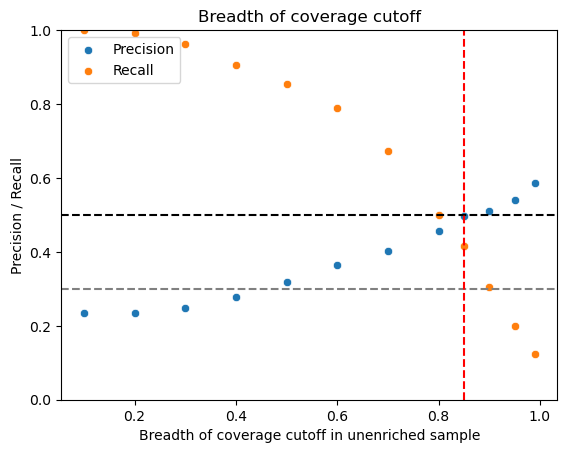

In [12]:
### breadth of coverage cutoffs
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.85, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth of coverage cutoff in unenriched sample')
plt.ylabel('Precision / Recall')
plt.title('Breadth of coverage cutoff')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

1.0


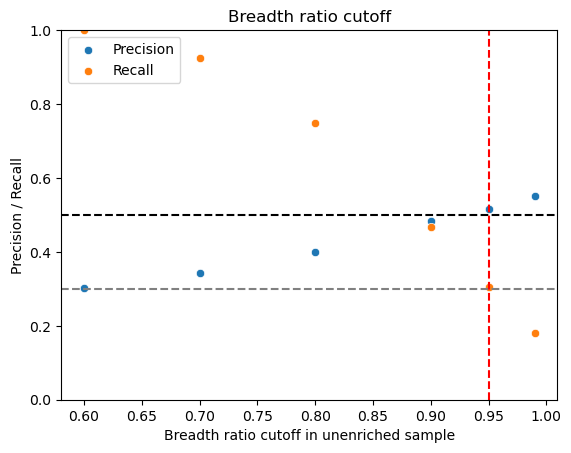

In [13]:
### breadth ratio of coverage cutoffs
precision_values = []
recall_values = []

print(enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.95, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth ratio cutoff in unenriched sample')
plt.ylabel('Precision / Recall')
plt.title('Breadth ratio cutoff')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.5785797438882422


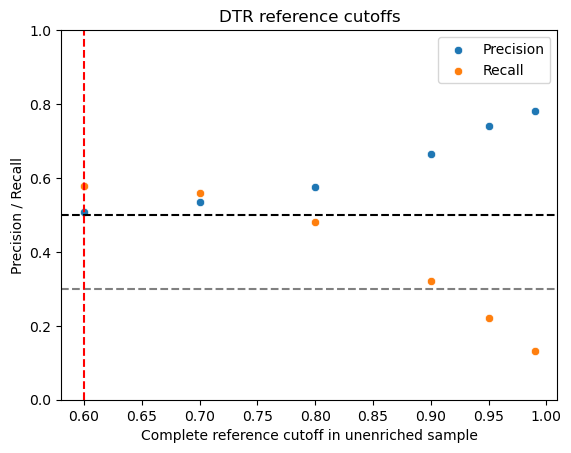

In [14]:
### Reference DTR
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter(pl.col('circular_count') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter(pl.col('breadth_ratio') >= i)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('circular_count') > 0)
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.6, color='red', linestyle='--')
plt.xlabel('Complete reference cutoff in unenriched sample')
plt.ylabel('Precision / Recall')
plt.title('DTR reference cutoffs')
plt.ylim(0,1)
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.9976717112922002


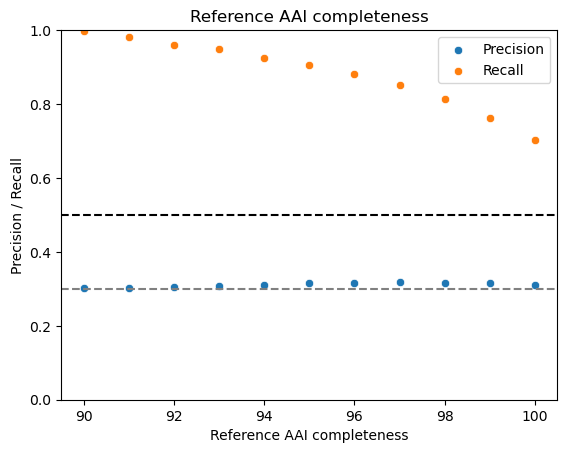

In [15]:
### 100% complete virus
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('aai_completeness') >= 90)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]:
    if (enrich_v_unenrich
            .filter(pl.col('aai_completeness') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('aai_completeness') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('aai_completeness') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('aai_completeness') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100],
    y=precision_values
)
sns.scatterplot(
    x=[90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Reference AAI completeness')
plt.ylabel('Precision / Recall')
plt.title('Reference AAI completeness')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.06635622817229336


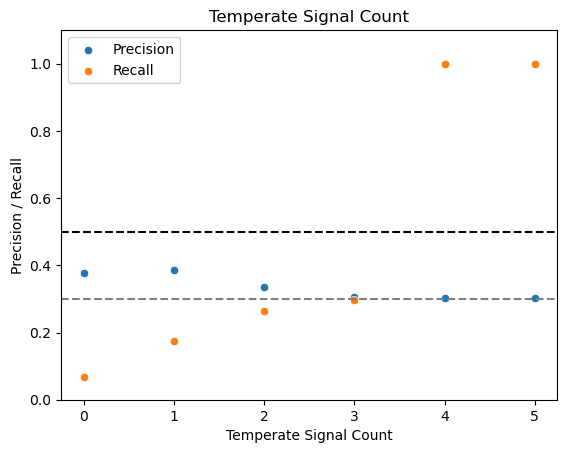

In [16]:
### Temperate signal count
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('temperate_signal_count') == 0.0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [ 0, 1, 2, 3, 4, 5]:
    if (enrich_v_unenrich
            .filter(pl.col('temperate_signal_count') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('temperate_signal_count') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('temperate_signal_count') <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('temperate_signal_count') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Temperate Signal Count')
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.title('Temperate Signal Count')
plt.show()

0.7788125727590222


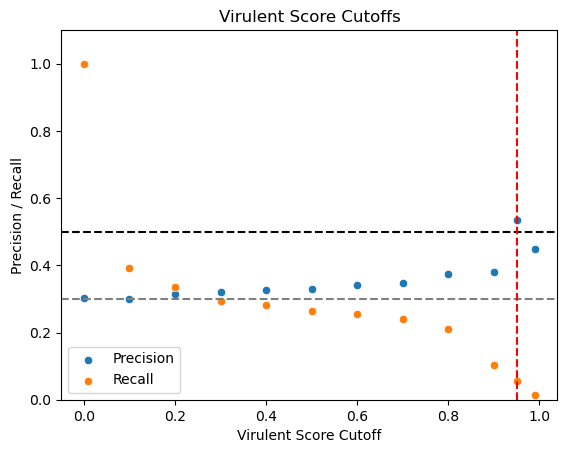

In [17]:
### Virulent score cutoffs
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('bacphlip_virulent_score') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('bacphlip_virulent_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('bacphlip_virulent_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('bacphlip_virulent_score') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('bacphlip_virulent_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.95, color='red', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Virulent Score Cutoff')
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.title('Virulent Score Cutoffs')
plt.show()

0.6682188591385332


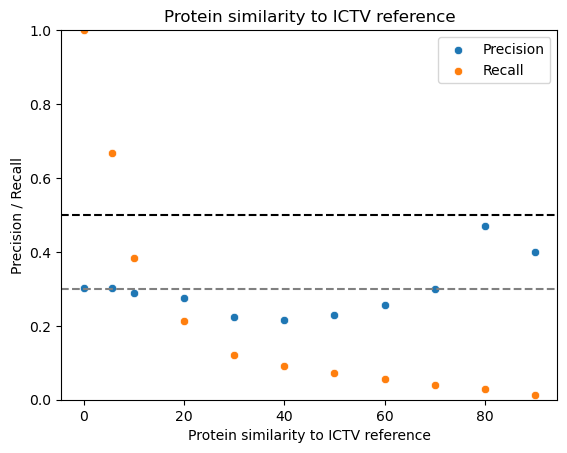

In [18]:
### Protein similarity to ICTV reference
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('normscore') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ]:
    if (enrich_v_unenrich
            .filter(pl.col('normscore') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('normscore') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('normscore') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('normscore') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Protein similarity to ICTV reference')
plt.ylabel('Precision / Recall')
plt.title('Protein similarity to ICTV reference')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.06752037252619325


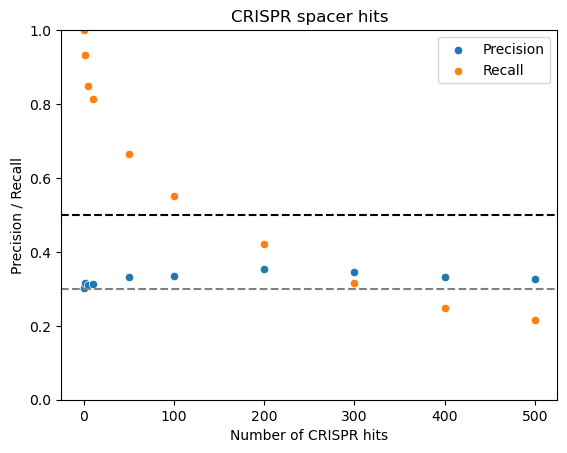

In [19]:
### CRISPR spacer hit count
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('crispr_family_connection_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 1, 5, 10, 50, 100, 200, 300, 400, 500]:
    if (enrich_v_unenrich
            .filter(pl.col('crispr_family_connection_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('crispr_family_connection_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('crispr_family_connection_count') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('crispr_family_connection_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 5, 10, 50, 100, 200, 300, 400, 500],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 5, 10, 50, 100, 200, 300, 400, 500],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Number of CRISPR hits')
plt.ylabel('Precision / Recall')
plt.title('CRISPR spacer hits')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.09545983701979045


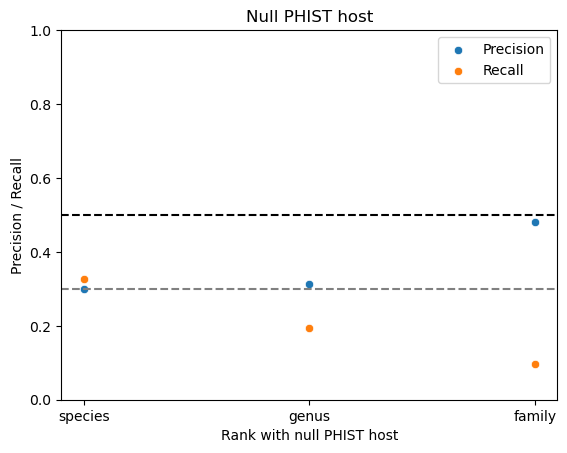

In [20]:
### Lack of PHIST host
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('phist_family').is_null())
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 'species', 'genus', 'family' ]:
    if (enrich_v_unenrich
            .filter(pl.col(f'phist_{i}').is_null())
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col(f'phist_{i}').is_null())
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col(f'phist_{i}').is_null())
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col(f'phist_{i}').is_null())
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 'species', 'genus', 'family' ],
    y=precision_values
)
sns.scatterplot(
    x=[ 'species', 'genus', 'family' ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Rank with null PHIST host')
plt.ylabel('Precision / Recall')
plt.title('Null PHIST host')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

1.0


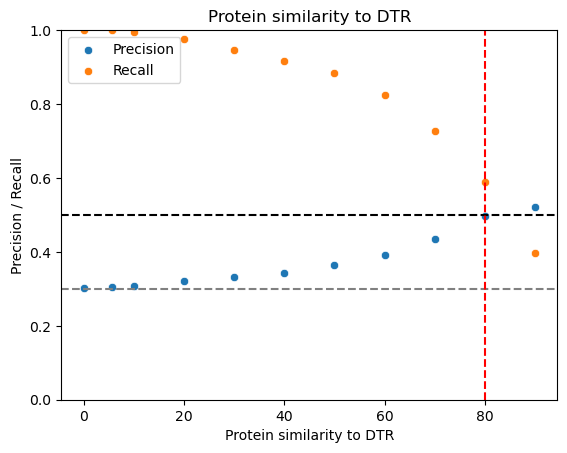

In [21]:
### Protein similarity to DTR
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('aai_id') * 0.01 *  pl.col('aai_af') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ]:
    if (enrich_v_unenrich
            .filter(pl.col('aai_id') * 0.01 *  pl.col('aai_af') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('aai_id') * 0.01 *  pl.col('aai_af') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('aai_id') * 0.01 *  pl.col('aai_af') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('aai_id') * 0.01 *  pl.col('aai_af') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=80, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Protein similarity to DTR')
plt.ylabel('Precision / Recall')
plt.title('Protein similarity to DTR')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

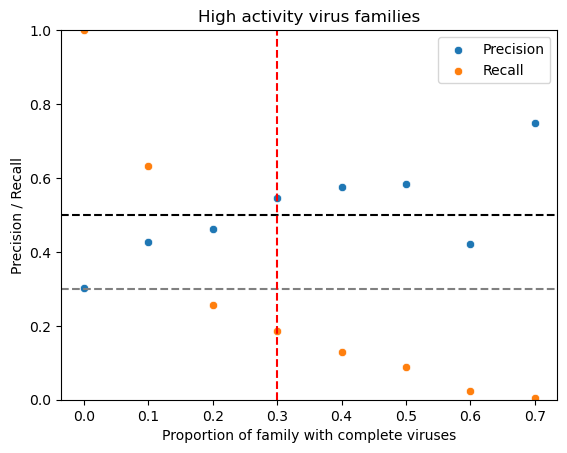

In [22]:
### Belonging to a family with a high proportion of complete viruses
precision_values = []
recall_values = []

for i in [ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 ]:
    active_families = set(
        combined
            .group_by('family_cluster_id')
            .agg([
                ((pl.col('checkv_quality') == 'Complete').sum() / pl.len()).alias('complete_ratio'),
                pl.len().alias('total_count')
            ])
            .filter(pl.col('total_count') >= 1)
            .filter(pl.col('complete_ratio') >= i)
            ['family_cluster_id']
    )
    
    if (enrich_v_unenrich
            .filter(pl.col('family_cluster_id').is_in(active_families))
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('family_cluster_id').is_in(active_families))
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('family_cluster_id').is_in(active_families))
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('family_cluster_id').is_in(active_families))
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.3, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Proportion of family with complete viruses')
plt.ylabel('Precision / Recall')
plt.title('High activity virus families')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

In [23]:
### create finalized host predictions
uhvdb_combinedhost =(
    pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_phisthost.tsv.gz', separator='\t')[['uhvdb_id', 'total_connections', 'rank', 'agreement', 'consensus_taxonomy']]
        .join(
            pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_crisprhost.tsv.gz', separator='\t')[['uhvdb_id', 'total_connections', 'rank', 'agreement', 'top_taxonomy']],
            on=['uhvdb_id', 'rank'],
            how='full',
            suffix='_crispr'
        )
        .fill_null(0)
        .with_columns([
            pl.col('consensus_taxonomy').str.replace(r'^(s|g|f)__', ''),
        ])
        .with_columns([
            pl.when(pl.col('consensus_taxonomy') == pl.col('top_taxonomy')).then(pl.col('consensus_taxonomy'))
                .when((pl.col('total_connections') * pl.col('agreement')) >= (pl.col('total_connections_crispr') * pl.col('agreement_crispr'))).then(pl.col('consensus_taxonomy'))
                .otherwise(pl.col('top_taxonomy'))
                .alias('final_taxonomy'),
            pl.when(pl.col('rank').is_not_null()).then(pl.col('rank')).otherwise(pl.col('rank_crispr')).alias('final_rank'),
            pl.when(pl.col('uhvdb_id').is_not_null()).then(pl.col('uhvdb_id')).otherwise(pl.col('uhvdb_id_crispr')).alias('final_id'),
            pl.when(pl.col('consensus_taxonomy') == pl.col('top_taxonomy')).then(pl.lit('methods_agree'))
                .when((pl.col('total_connections') * pl.col('agreement')) >= (pl.col('total_connections_crispr') * pl.col('agreement_crispr'))).then(pl.lit('phist_preferred'))
                .otherwise(pl.lit('crispr_preferred'))
                .alias('final_taxonomy_source'),
        ])
        .group_by('final_id')
        .agg([
            pl.col('final_taxonomy').filter(pl.col('final_rank') == 'species').first().alias('final_species'),
            pl.col('final_taxonomy_source').filter(pl.col('final_rank') == 'species').first().alias('final_species_source'),

            pl.col('final_taxonomy').filter(pl.col('final_rank') == 'genus').first().alias('final_genus'),
            pl.col('final_taxonomy_source').filter(pl.col('final_rank') == 'genus').first().alias('final_genus_source'),

            pl.col('final_taxonomy').filter(pl.col('final_rank') == 'family').first().alias('final_family'),
            pl.col('final_taxonomy_source').filter(pl.col('final_rank') == 'family').first().alias('final_family_source'),
        ])
        .with_columns([
            pl.when(pl.col('final_species').is_not_null())
                .then(pl.col('final_species'))
                .when(pl.col('final_genus').is_not_null())
                .then(pl.col('final_genus'))
                .when(pl.col('final_family').is_not_null())
                .then(pl.col('final_family'))
                .otherwise(pl.lit(None))
                .alias('final_taxonomy')
        ])
)

In [24]:
# import taxopy
# url_r226 = "https://github.com/shenwei356/gtdb-taxdump/releases/download/v0.6.0/gtdb-taxdump-R226.tar.gz"
# taxdb_r226 = taxopy.TaxDb(
#     taxdump_url=url_r226
# )
# url_r220 = "https://github.com/shenwei356/gtdb-taxdump/releases/download/v0.5.0/gtdb-taxdump-R220.tar.gz"
# taxdb_r220 = taxopy.TaxDb(
#     taxdump_url=url_r220
# )

In [25]:
# # 1) list all unique species names
# unique_final_species = (
#     uhvdb_combinedhost
#         .select('final_taxonomy')
#         .drop_nulls()
#         .unique()
#         .to_series()
#         .to_list()
# )

# # rank order + prefixes
# rank_prefix = [
#     ('superkingdom', 's__'),
#     ('phylum', 'p__'),
#     ('class', 'c__'),
#     ('order', 'o__'),
#     ('family', 'f__'),
#     ('genus', 'g__'),
#     ('species', 's__'),
# ]

# # 2) build mapping: species -> prefixed lineage
# species_to_lineage = {}
# for species in unique_final_species:
#     taxids = taxopy.taxid_from_name(species, taxdb_r226)
#     if not taxids:
#         continue

#     taxid = taxids[0]
#     taxon = taxopy.Taxon(taxid, taxdb_r226)
#     rank_name = taxon.rank_name_dictionary

#     lineage_parts = [
#         f"{prefix}{rank_name[rank]}"
#         for rank, prefix in rank_prefix
#         if rank in rank_name and rank_name[rank] is not None
#     ]
#     lineage = ';'.join(lineage_parts)  # no spaces between ranks
#     species_to_lineage[species] = lineage

In [26]:
# # 3) replace final_species with lineage using polars replace
# uhvdb_combinedhost = (
#     uhvdb_combinedhost
#         .with_columns([
#             pl.col('final_taxonomy').replace(species_to_lineage).str.replace(r'^s__', 'd__').alias('final_lineage'),
#         ])
# )

# print(uhvdb_combinedhost.filter(pl.col('final_lineage').is_not_null()).height)
# print(uhvdb_combinedhost.filter(pl.col('final_taxonomy').is_not_null()).height)

In [27]:
# ## load uhvdb taxonomy outputs
# df_lst = []

# for file in glob.glob('../figure_1/*_results/*_outputs/taxonomy/new_genomovars_ictv_taxonomy.tsv.gz'):
#     df = pl.read_csv(file, separator='\t')
#     df_lst.append(df)

# taxonomy_df = pl.concat(df_lst).sort('normscore', descending=True).unique('uhvdb_id', maintain_order=True)

In [28]:
# uhvdb_metadata = (
#     uhvdb_combinedhost
#         .join(combined.unique('genomovar_rep'), left_on='final_id', right_on='genomovar_rep', how='right')
#         .with_columns([
#             (
#                 pl.lit('vFAM-') + pl.col('family_cluster_id').cast(pl.String)
#                 + pl.lit(';vSUBFAM-') + pl.col('subfamily_cluster_id').cast(pl.String)
#                 + pl.lit(';vGENUS-') + pl.col('genus_cluster_id').cast(pl.String)
#                 + pl.lit(';vSUBGENUS-') + pl.col('subgenus_cluster_id').cast(pl.String)
#                 + pl.lit(';vSPECIES-') + pl.col('cluster_id').cast(pl.String)
#             )
#             .alias('final_virus_taxonomy')
#         ])
# )

In [29]:
# ### create finalized host predictions
# uhvdb_metadata_votu = (
#     uhvdb_metadata
#         .group_by(['votu_rep'])
#         .agg([
#             # identify most prevalent lifestyle
#             pl.col('final_virus_taxonomy').value_counts(sort=True).first().struct.field('final_virus_taxonomy').alias('final_virus_taxonomy'),
#             pl.col('final_lineage').value_counts(sort=True).first().struct.field('final_lineage').alias('final_lineage'),
#             # identify counts of most prev lifestyle
#             pl.col('final_virus_taxonomy').value_counts(sort=True).first().struct.field('count').alias('virus_taxonomy_count'),
#             pl.col('final_lineage').value_counts(sort=True).first().struct.field('count').alias('final_lineage_count'),
#             # identify total counts of all lifestyles
#             pl.len().alias('total_votu_count')
#         ])
#         .with_columns([
#             (pl.col('virus_taxonomy_count')/pl.col('total_votu_count')).alias('virus_taxonomy_proportion'),
#             (pl.col('final_lineage_count')/pl.col('total_votu_count')).alias('final_lineage_proportion'),
#         ])
# )
# uhvdb_metadata_votu[['votu_rep', 'final_virus_taxonomy', 'final_lineage']].write_csv('sylph_tax/uhvdb_v4_metadata.tsv', separator='\t', include_header=False)

In [30]:
%%bash 

# micromamba install -c conda-forge -c bioconda sylph-tax -y

# sylph-tax download --download-to sylph_tax

# for file in activity_profiling/liang_enriched_results/2026-04-03_outputs/referenceanalyze/sylph/liang_*enriched/liang_*enriched.profile.tsv.gz; do
#     gunzip -c ${file} > ${file%.gz}

#     # get file basename
#     prefix=$(basename ${file%.tsv.gz})
#     echo sylph_tax_results/${prefix}
#     echo ${file%.gz}

#     sylph-tax taxprof \
#         "${file%.gz}" \ß
#         -t sylph_tax/uhvdb_v4_metadata.tsv.gz GTDB_r226 \
#         -a \
#         -o "sylph_tax_results/${prefix}"
        
# done

# sylph-tax merge sylph_tax_results/* \
#     --column relative_abundance \
#     -o merged_sylph_tax_results.tsv

In [31]:
phage_host_ratio_lst = []

for file in glob.glob('sylph_tax_results/liang_*enriched.profileliang_*unenriched_R1.fastq.gz.sylphmpa'):
    sample_id=file.split('/')[-1].split('.profile')[0]
    df = pl.read_csv(file, separator='\t', skip_rows=1, new_columns=['clade_name', 'taxonomic_abundance', 'relative_abundance', 'ani', 'coverage', 'virus_host'], null_values=['NA'])
    virus_df = df.filter(pl.col('virus_host').is_not_null()).with_columns([pl.col('virus_host').str.replace_all(';', '|')])
    bac_df = df.filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
    phage_host_ratio_lst.append(
        virus_df
            .join(bac_df, left_on='virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('phage_host_ratio'),
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep')
            ])
    )

phage_host_ratio_df = pl.concat(phage_host_ratio_lst)

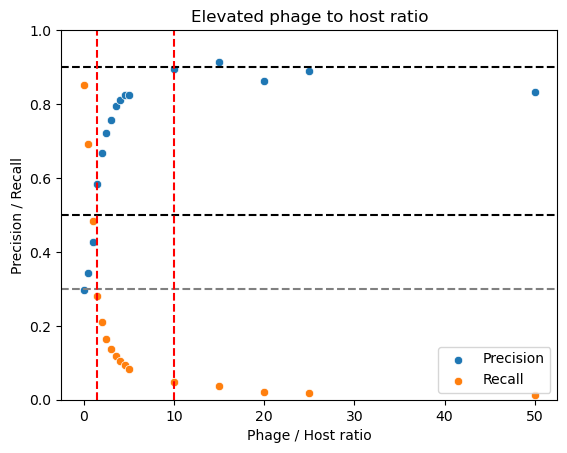

In [32]:
### Belonging to a family with a high proportion of complete viruses
precision_values = []
recall_values = []

for i in [ 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3, 3.5, 4, 4.5, 5, 10, 15, 20, 25, 50 ]:
    active_phages = (
        phage_host_ratio_df
            .filter(pl.col('phage_host_ratio') >= i)
            .with_columns([pl.col('clade_name').str.split('t__').list[1].alias('votu_rep')])
            ['sample_id', 'votu_rep']
    )

    
    if (enrich_v_unenrich
            .join(active_phages, left_on=['sample_id', 'contig_id'], right_on=['sample_id', 'votu_rep'], how='inner')
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .join(active_phages, left_on=['sample_id', 'contig_id'], right_on=['sample_id', 'votu_rep'], how='inner')
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .join(active_phages, left_on=['sample_id', 'contig_id'], right_on=['sample_id', 'votu_rep'], how='inner')
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .join(active_phages, left_on=['sample_id', 'contig_id'], right_on=['sample_id', 'votu_rep'], how='inner')
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3, 3.5, 4, 4.5, 5, 10, 15, 20, 25, 50 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3, 3.5, 4, 4.5, 5, 10, 15, 20, 25, 50 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axhline(y=0.9, color='black', linestyle='--')
plt.axvline(x=1.5, color='red', linestyle='--')
plt.axvline(x=10, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Phage / Host ratio')
plt.ylabel('Precision / Recall')
plt.title('Elevated phage to host ratio')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

In [39]:
# combine all data together
active_families = set(
        combined
            .group_by('family_cluster_id')
            .agg([
                ((pl.col('checkv_quality') == 'Complete').sum() / pl.len()).alias('complete_ratio'),
                pl.len().alias('total_count')
            ])
            .filter(pl.col('total_count') >= 1)
            .filter(pl.col('complete_ratio') >= 0.3)
            ['family_cluster_id']
    )

enrich_v_unenrich = (
    coverm_df[['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'trimmed_mean']]
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(
            coverm_df[['contig_id', 'sample_id', 'group', 'breadth', 'breadth_ratio', 'trimmed_mean']].filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='full'
        )
        # .with_columns([
        #     pl.when(pl.col('contig_id').is_not_null())
        #         .then(pl.col('contig_id'))
        #         .otherwise(pl.col('contig_id_enriched'))
        #         .alias('contig_id')
        # ])
        .join(lifestyle_df[['votu_rep', 'bacphlip_virulent_score']], left_on='contig_id', right_on='votu_rep', how='left')
        .join(hqfilter_df[['votu_rep', 'aai_id', 'aai_af', 'family_cluster_id']], left_on='contig_id', right_on='votu_rep', how='left')
        .join(classify_df[['votu_rep', 'circular_count']], left_on='contig_id', right_on='votu_rep', how='left')
        .join(phage_host_ratio_df[['votu_rep', 'sample_id', 'phage_host_ratio']], left_on=['contig_id', 'sample_id'], right_on=['votu_rep', 'sample_id'], how='left')
        .unique(['contig_id', 'sample_id'])
        .with_columns([
            # breadth of coverage as an indicator that a virus is not fragmented
            pl.when((pl.col('breadth') >= 0.85) | (pl.col('breadth_ratio') >= 0.95)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_breadth_score'),
            # reference evidence of activity
            pl.when((pl.col('circular_count') > 0) | (pl.col('family_cluster_id').is_in(active_families)) | ((pl.col('aai_id') * 0.01 *  pl.col('aai_af')) >= 80)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_tr_score'),
            pl.when((pl.col('bacphlip_virulent_score') >= 0.95)).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_virulent_score'),
            pl.when(pl.col('phage_host_ratio') >= 10).then(pl.lit(4.0))
                .when(pl.col('phage_host_ratio') >= 1.5).then(pl.lit(1.0))
                .otherwise(pl.lit(0.0)).alias('ref_phage_host_ratio_score')
        ])
        .with_columns([
            (
                pl.col('ref_breadth_score') +
                pl.col('ref_tr_score') +
                pl.col('ref_virulent_score') +
                pl.col('ref_phage_host_ratio_score')
            ).alias('ref_activity_score')
        ])
        .fill_null(0.00)
)
enrich_v_unenrich.height

3682

In [40]:
print("Number of true positives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false negatives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false positives:", enrich_v_unenrich.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6)).height)

enrich_v_unenrich = (
    enrich_v_unenrich
        .with_columns([
            pl.when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('TP'))
                .when((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('FN'))
                .when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6))
                .then(pl.lit('FP'))
                .otherwise(pl.lit('TN'))
                .alias('pr_cat')
        ])
)

Number of true positives: 859
Number of false negatives: 22
Number of false positives: 1983


In [42]:
(
    enrich_v_unenrich
        .with_columns([
            (pl.col('ref_breadth_score') > 0).sum().alias('num_ref_breadth_score'),
            (pl.col('ref_tr_score') > 0).sum().alias('num_ref_tr_score'),
            (pl.col('ref_virulent_score') > 0).sum().alias('num_ref_virulent_score'),
            (pl.col('ref_phage_host_ratio_score') > 0).sum().alias('num_ref_phage_host_ratio_score'),
        ])
        [['num_ref_breadth_score', 'num_ref_tr_score', 'num_ref_virulent_score', 'num_ref_phage_host_ratio_score']]
        .head(1)
)

num_ref_breadth_score,num_ref_tr_score,num_ref_virulent_score,num_ref_phage_host_ratio_score
u32,u32,u32,u32
858,1427,99,489


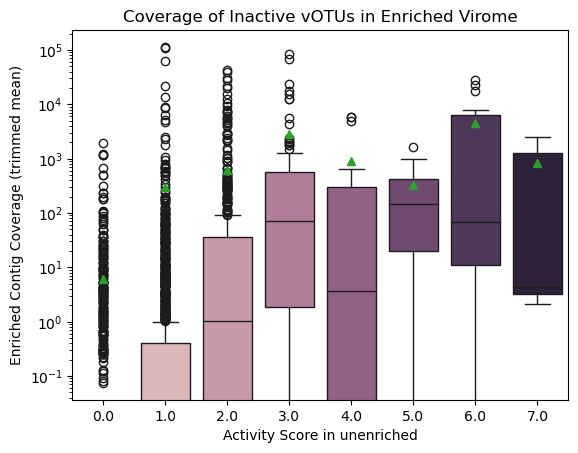

In [43]:
sns.boxplot(
    data=enrich_v_unenrich.filter((pl.col('trimmed_mean') > 0.0)),
    x='ref_activity_score',
    y='trimmed_mean_enriched',
    hue='ref_activity_score',
    showmeans=True
)
plt.yscale('log')
plt.xlabel('Activity Score in unenriched')
plt.ylabel('Enriched Contig Coverage (trimmed mean)')
plt.title('Coverage of Inactive vOTUs in Enriched Virome')
# hide legend
plt.legend().remove()
plt.show()

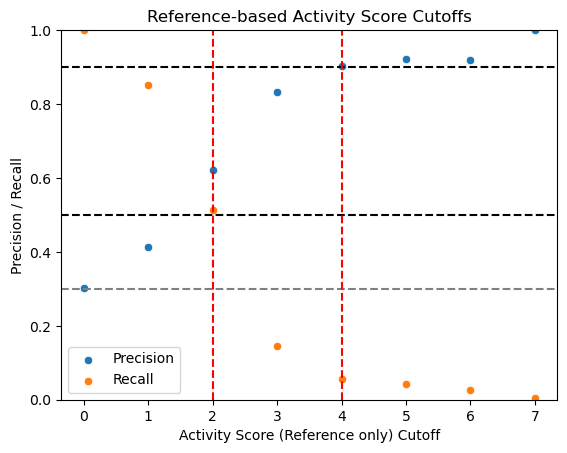

In [45]:
precision_values = []
recall_values = []

for i in [0, 1, 2, 3, 4, 5, 6, 7, 8]:
    if (enrich_v_unenrich
            .filter(pl.col('ref_activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('ref_activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('ref_activity_score') >= i)
            .filter((pl.col('breadth_ratio') >= 0.6))
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('ref_activity_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )


# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 6, 7, 8],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 6, 7, 8],
    y=recall_values
)
# plt.axvline(x=1, color='red', linestyle='--')
# plt.axvline(x=3, color='red', linestyle='--')
# plt.axvline(x=5, color='red', linestyle='--')
# plt.axhline(y=0.8, color='grey', linestyle='--')
plt.axhline(y=0.9, color='black', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axvline(x=2, color='red', linestyle='--')
plt.axvline(x=4, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Activity Score (Reference only) Cutoff')
plt.ylabel('Precision / Recall')
plt.title('Reference-based Activity Score Cutoffs')
plt.legend(labels=['Precision', 'Recall'])
plt.show()